# Learning the OS Module in Python for Data Engineers

This notebook provides a structured learning path and practice questions for the Python `os` module, focused on file and directory operations relevant to data engineering tasks like ETL, data organization, and pipeline automation.

## Level 1: Basic Theory and Commands

Basic theory and commands to know and practice problems

### 1. Introduction to the OS Module
- **What to Learn**: Basics of the `os` module for OS interactions.
- **Key Functions**: `os.getcwd()`, `os.chdir()`, `os.listdir()`.
- **Tip**: Import with `import os`.

In [ ]:
import os
print('Current directory:', os.getcwd())
print('Files in current directory:', os.listdir('.'))
print('Parent directory:', os.path.dirname(os.getcwd()))
#print('Change to parent directory:', os.chdir(os.path.dirname(os.getcwd())))
print('Current directory after change:', os.getcwd())




### 2. Directory Operations
- **Key Functions**: `os.mkdir()`, `os.makedirs()`, `os.rmdir()`, `os.walk()`.
- **Data Engineering Use**: Organize data folders.

### Making Directory

In [ ]:
# Create a directory
#os.rmdir('data_practice')  # Remove the directory if it already exists for a clean slate
#os.rmdir('data_practice1')  # Remove the directory if it already exists for a clean slate

os.makedirs('data_practice', exist_ok=True)
os.mkdir('data_practice1')
print('Directory created:', os.listdir('.'))

# makedirs : If we give the full path to create a subdirectory, it will create all the intermediate directories if they do not exist. Also if we just give the name of the subdirectory, it will create it in the current directory.
# exist_ok=True allows the directory to be created if it does not exist, and prevents an error if it already exists.

print('Subdirectory created:', os.listdir('.'))
# mkdir : If we give the full path to create a subdirectory, and it will throw an error if the parent directory does not exist. Also if we just give the name of the subdirectory, it will create it in the current directory.
os.mkdir('data/subdir1')

# mkdir : if the directory already exists, it will throw an error. It does not have the exist_ok parameter like makedirs.
os.mkdir('data_practice1') # Already created above, so it will throw an error.


### Removing Directory

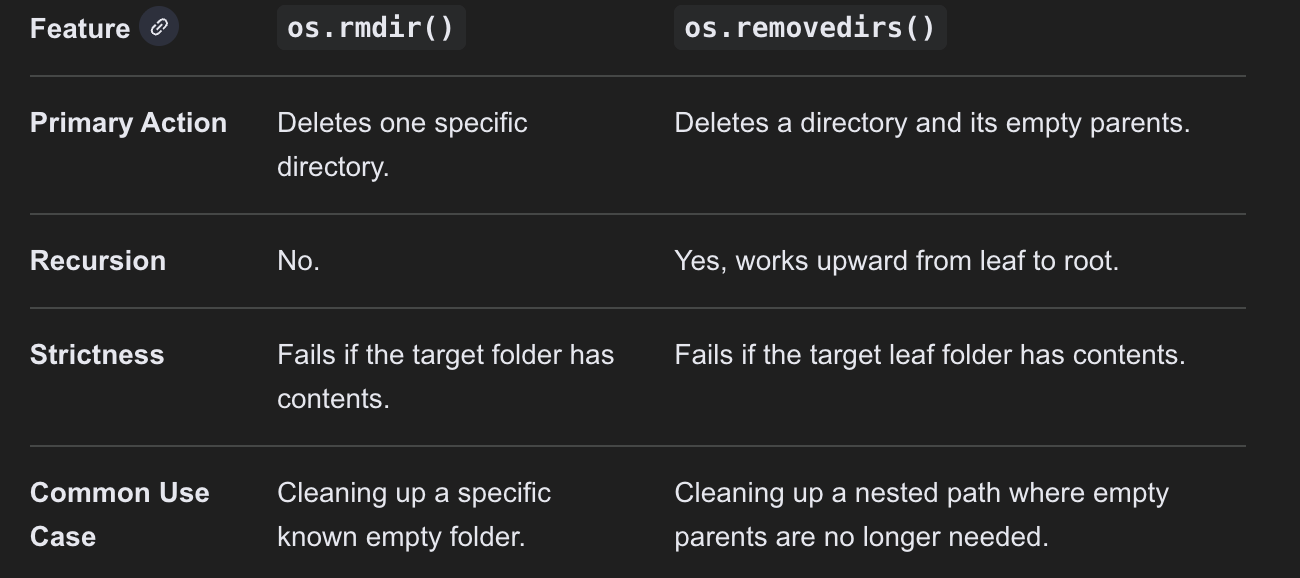


In [ ]:
# Removing directories
os.rmdir('data_practice1')  # Remove the directory

print('Directory removed:', os.listdir('.'))

In [ ]:
# Walk through the directory tree and print the directories and files
print(os.getcwd())
for root, dirs, files in os.walk('.'):
    print(f"Directory: {root}")
    for d in dirs:
        print(f"  Subdirectory: {d}")
    for f in files:
        print(f"  File: {f}")

### 3. File Operations
- **Key Functions**: `os.rename()`, `os.remove()`, `os.path.exists()`.
- **Note**: Pair with `shutil` for copying.

In [ ]:
# Check file existence
os.chdir('/Users/priyansh/Python')
print(f'README.md exists at path {os.getcwd()}:', os.path.exists('README.md'))

os.chdir('/Users/priyansh/Python/OS')
print(f'README.md exists at path {os.getcwd()}:', os.path.exists('README.md'))


# Rename 
os.rename('data_practice', 'data_renamed')
#os.rename('data_renamed', 'data_practice')
print('Directory renamed:', os.listdir('.'))


#Remove
# os.remove() is used to remove a file, while os.rmdir() is used to remove an empty directory. If you want to remove a directory that contains files or subdirectories, you can use shutil.rmtree() from the shutil module.
os.chdir('/Users/priyansh/Python/OS/data_renamed')
os.system('touch file1.txt')  # Create a file named file1.txt
print(os.listdir('.'))  # List files in the current directory
os.remove('file1.txt')  # Remove the file created above, also os.unlink() can be used to remove a file, it is an alias for os.remove()
print('File removed:', os.listdir('.'))

### File creation 

In [ ]:
os.system('touch file2.txt')  # Create a file named file2.txt
print(os.listdir('.'))  # List files in the current directory
with open('file2.txt','w') as f:
    f.write('Hello, World!')  # Write some content to the file
print('File content written:', os.listdir('.'))

## Shutil

In [ ]:

import shutil


shutil.copy('file2.txt', 'file2_copy.txt')  # Copy file2.txt to file2_copy.txt
print('File copied:', os.listdir('.'))

## Level 2: Intermediate Level Concepts

Intermediate level concepts with theory, commands and practice problems

### 4. Path Manipulations
- **Key Functions**: `os.path.join()`, `os.path.split()`, `os.path.abspath()`.
- **Use**: Build safe paths.

In [ ]:
# Join paths
print(">>>Join Paths:")
path = os.path.join('data_practice', 'file.txt')
print('Joined path:', path) 

#joining absolute path
abs_path = os.path.join(os.getcwd(), 'data_practice', 'file.txt')
print('Joined absolute path:', abs_path)

# Normalize path
print("\n>>>Normalize Paths:")
path_with_dots = 'data_practice/../data_practice/file.txt'
normalized_path = os.path.normpath(path_with_dots)
print('Normalized path:', normalized_path)  # This will resolve the '..' to give a cleaner path
# normalise path : os.path.normpath() is used to normalize a path by collapsing redundant separators and up-level references. It does not check if the path exists, it simply processes the string to produce a cleaner path.

# Split paths
print("\n>>>Split Paths:")
dir_name, file_name = os.path.split(path)
print('Directory name:', dir_name)
print('File name:', file_name)


# Difference between os.path.split and os.path.splitext
print("\n>>>Difference between os.path.split and os.path.splitext:")
file_name_with_ext = 'file.txt'
print(' ## providing only file name with extension to os.path.split:')
dir_name, file_name = os.path.split(file_name_with_ext)
print('Directory name:', dir_name)  # This will be empty since there is no directory
print('File name:', file_name)  # This will be 'file.txt'

# Using os.path.splitext to separate file name and extension
print('  ## providing only file name with extension to os.path.splitext:')
file_name, file_ext = os.path.splitext(file_name_with_ext)
print('File name (without extension):', file_name)  # This will be 'file'
print('File extension:', file_ext)  # This will be '.txt'

print("\n>>>Using os.path.splitext with full path:")
#whatbis we provide ful path to  os.path.splitext
full_path = '/Users/priyansh/Python/OS/data_practice/file.txt'
file_name, file_ext = os.path.splitext(full_path)
print('File name (without extension):', file_name)  # This will be '/Users/priyansh/Python/OS/data_practice/file'
print('File extension:', file_ext)  # This will be '.txt'

# Checking directory and file existence
print("\n>>>Checking directory and file existence:")
print(f'Current directory: {os.getcwd()}')
print(os.listdir('.'))  # List files in the current directory
print('Does data_practice directory exist?', os.path.isdir('data_renamed'))
print('Does file2.txt exist?', os.path.isfile('file2.txt'))

os.chdir('/Users/priyansh/Python/OS')
print(f'Current directory: {os.getcwd()}')
print(os.listdir('.'))  # List files in the current directory
print('Does data_practice directory exist?', os.path.isdir('data_renamed'))
print('Does data_practice file exist?', os.path.isfile('data_renamed'))
print('Does file2.txt exist?', os.path.isfile('file2.txt'))



### 5. File Metadata and Permissions
- **Key Functions**: `os.stat()`, `os.getsize()`, `os.chmod()`.
- **Use**: Check file sizes and timestamps.

In [ ]:
# Get file size (if README.md exists)
if os.path.exists('README.md'):
    print('README.md size:', os.path.getsize('README.md'))

### 6. Environment Variables and System Info
- **Key Functions**: `os.environ`, `os.getenv()`, `os.name`.
- **Use**: Access configs and system details.

In [ ]:
# Get OS name
print('OS:', os.name)
print('Home:', os.getenv('HOME'))

## Level 3: Advanced Topics

Advanced topics and commands and practice problems

### 7. Advanced Topics
- **Tips**: Use `pathlib` for modern paths. Handle errors with try-except.
- **Best Practice**: Avoid `os.system()`; use `subprocess`.

## Practice Problems

### Level 1 Practice Problems

**1. Get Current Directory**
Print the current working directory.

In [ ]:
# Your code here
import os
print(os.getcwd())

**2. List Directory Contents**
List all files and folders in the current directory.

In [ ]:
# Your code here
print(os.listdir('.'))

**3. Check if File Exists**
Check if 'README.md' exists.

In [ ]:
# Your code here
print(os.path.exists('README.md'))

### Level 2 Practice Problems

**4. Create a Directory**
Create a folder called 'data_engineering_practice'.

In [ ]:
# Your code here
os.makedirs('data_engineering_practice', exist_ok=True)

**5. Join Paths**
Create a path to 'data.txt' inside 'data_engineering_practice'.

In [ ]:
# Your code here
path = os.path.join('data_engineering_practice', 'data.txt')
print(path)

### Level 3 Practice Problems

**6. Create and Write to a File**
Create 'data.txt' in the folder and write 'Hello, Data Engineer!'.

In [ ]:
# Your code here
path = os.path.join('data_engineering_practice', 'data.txt')
with open(path, 'w') as f:
    f.write('Hello, Data Engineer!')

**7. Get File Size**
Print the size of 'data.txt'.

In [ ]:
# Your code here
path = os.path.join('data_engineering_practice', 'data.txt')
print(os.path.getsize(path))

**8. Rename a File**
Rename 'data.txt' to 'processed_data.txt'.

In [ ]:
# Your code here
old_path = os.path.join('data_engineering_practice', 'data.txt')
new_path = os.path.join('data_engineering_practice', 'processed_data.txt')
os.rename(old_path, new_path)

**9. Walk Through Directories**
List all files in the workspace recursively.

In [ ]:
# Your code here
for root, dirs, files in os.walk('.'):
    for file in files:
        print(os.path.join(root, file))

**10. Environment Variable**
Print the value of 'HOME'.

In [ ]:
# Your code here
print(os.getenv('HOME'))

In [ ]:
import os
print(os.getcwd())